# 03. Segmentation & Labeling

목표는 검은 선으로 둘러싸인 흰 영역을 색칠 가능한 영역으로 분리하고, 각 영역 중심에 색상 번호를 삽입하는 것입니다.

비교 알고리즘:

- Contour Detection: 외곽선을 추적해 영역 후보를 찾습니다.
- Connected Components Labeling: 연결된 흰 영역을 라벨로 분리합니다.
- Watershed: 거리 변환과 마커를 기반으로 영역을 나누는 비교용 방법입니다.

최종 기본 알고리즘은 Connected Components로 영역을 안정적으로 분리하고, Contour Detection을 보조 시각화에 사용합니다.

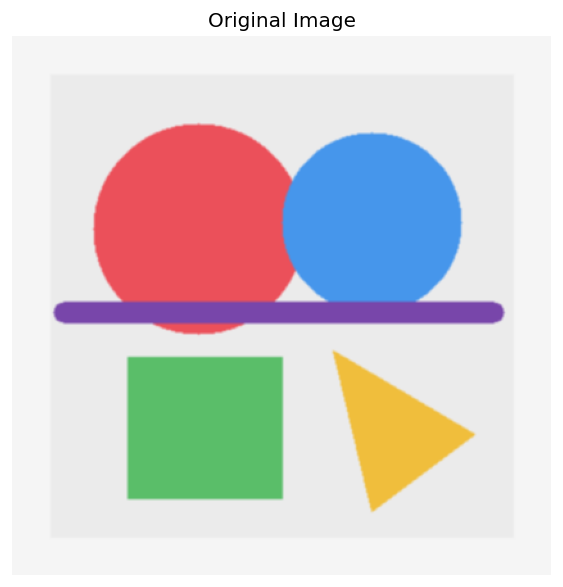

In [1]:
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
from coloringbook_utils import *

# 결과 저장 폴더(outputs)와 샘플 입력 폴더(data)를 생성합니다.
ensure_dirs()
plt.rcParams["figure.dpi"] = 120

# 직접 사용할 이미지가 있으면 여기에 경로를 넣으세요.
# 예: IMAGE_PATH = "data/my_image.jpg"
IMAGE_PATH = "data/sample_input.png"

# IMAGE_PATH가 None이면 발표/실험용 샘플 이미지가 자동 생성됩니다.
image = load_image(IMAGE_PATH)
show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 선화 생성 후 영역 분리

작은 영역은 색칠하기 어렵고 번호도 읽기 어렵기 때문에 `MIN_AREA`로 제거합니다.

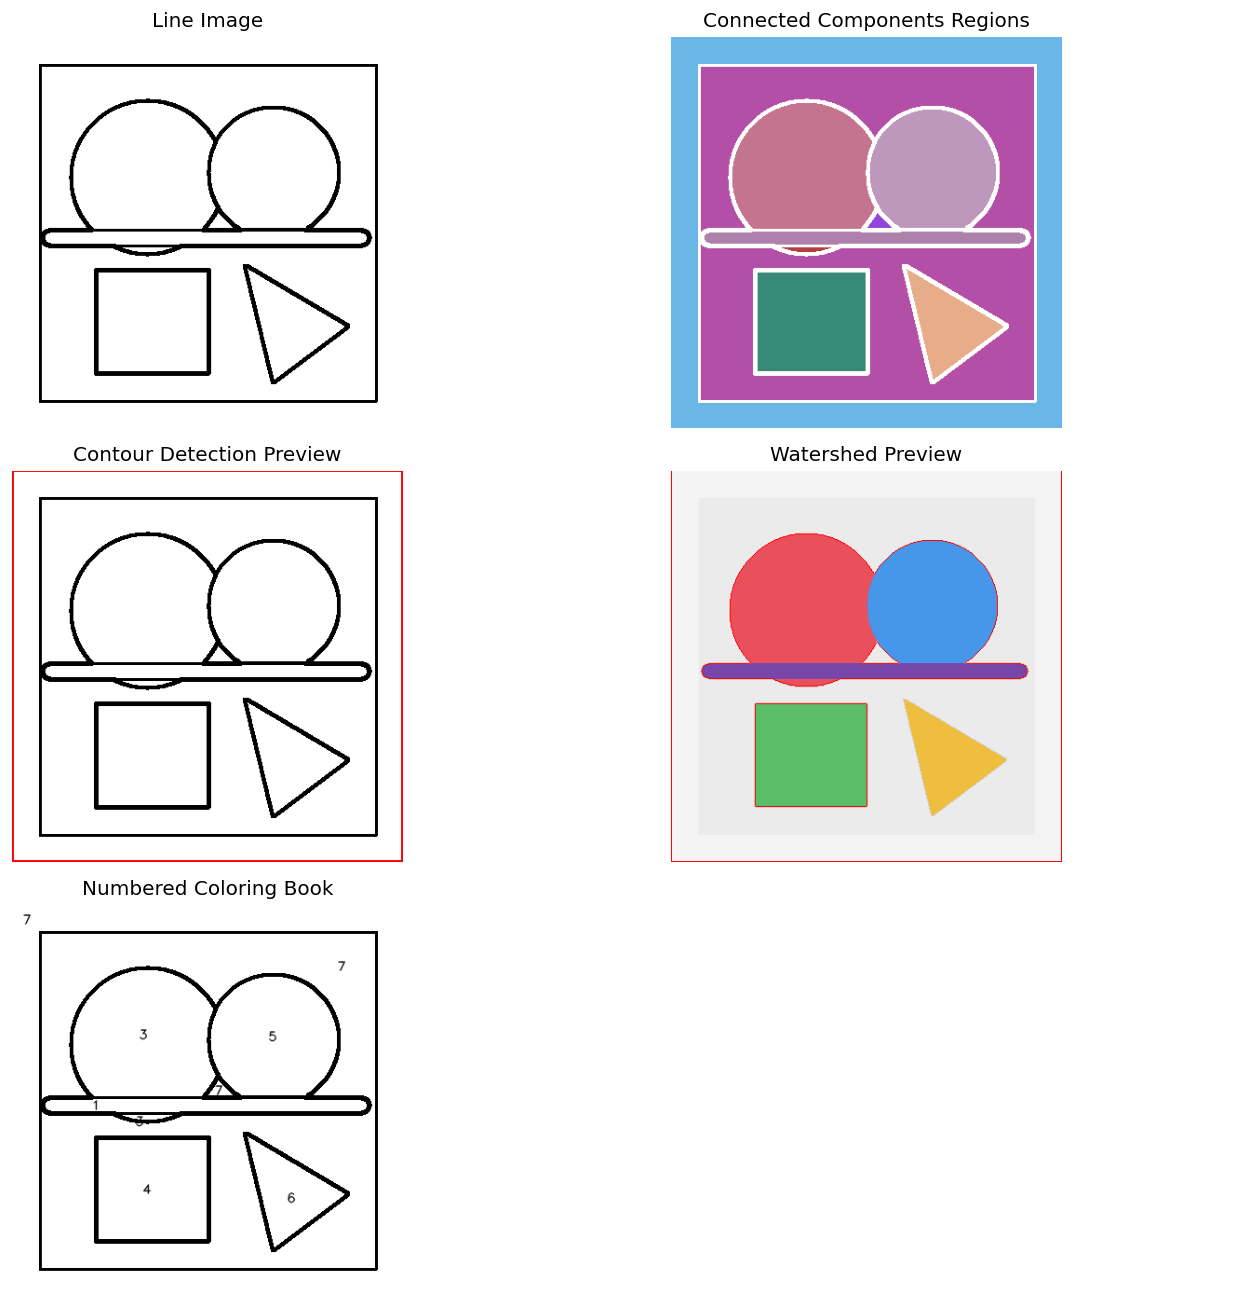

In [2]:
# K는 색상 단순화 정도, MIN_AREA는 번호를 넣을 최소 영역 크기입니다.
K = 10
MIN_AREA = 160

# 최종 기본 흐름: K-Means로 단순화한 뒤 Canny 선화를 만듭니다.
quantized, palette, label_map = kmeans_quantization_with_labels(image, K)
edges = clean_edges(hybrid_canny_color_edges(quantized, 60, 150, label_map), close_iter=1, thickness=2)
line_image = coloring_line_image(edges)

# Connected Components는 검은 선으로 분리된 흰 영역을 고유 영역 ID로 구분합니다.
(region_map, regions), cc_time = timed_call(segment_connected_components, line_image, MIN_AREA)

# 컬러링북에 들어가는 숫자는 영역 ID가 아니라 K-Means 팔레트 색상 번호입니다.
# 따라서 같은 색이 떨어진 여러 영역에 있어도 같은 숫자가 표시됩니다.
# 테두리에서 배경 RGB 색을 추정하고, Lab 색상 거리가 가까운 영역은 배경 번호로 병합합니다.
background_color = estimate_background_color(quantized)
regions = assign_region_color_numbers(
    regions,
    region_map,
    label_map,
    palette,
    background_color=background_color,
    background_color_threshold=16,
    merge_background_similar=True,
)
numbered_regions = colorable_regions(regions)
region_preview = color_region_preview(region_map)

# 각 닫힌 영역 내부에서 가장 넓은 지점에 색상 번호를 넣습니다.
# 예시 이미지처럼 같은 색상 번호가 여러 영역에 반복해서 표시됩니다.
numbered = label_regions(line_image, regions, font_scale=0.45, region_map=region_map)

# Contour와 Watershed는 비교용 결과로 함께 확인합니다.
contour_preview, contours = contour_regions(line_image, MIN_AREA)
watershed_preview, watershed_markers = watershed_segmentation(quantized)

save_image_rgb("outputs/03_line_image.png", line_image)
save_image_rgb("outputs/03_region_preview.png", region_preview)
save_image_rgb("outputs/03_numbered_coloringbook.png", numbered)
save_image_rgb("outputs/03_contour_preview.png", contour_preview)
save_image_rgb("outputs/03_watershed_preview.png", watershed_preview)

show_images([
    ("Line Image", line_image),
    ("Connected Components Regions", region_preview),
    ("Contour Detection Preview", contour_preview),
    ("Watershed Preview", watershed_preview),
    ("Numbered Coloring Book", numbered),
], cols=2, figsize=(12, 11), cmap="gray", save_path="outputs/03_segmentation_compare.png")

## 영역 중심 좌표와 색상 번호 정보

아래 표에서 `region_id`는 분리된 영역의 고유 번호이고, `color_id`는 실제 컬러링북에 표시되는 팔레트 번호입니다. `background_distance`가 작아 `is_background=True`인 영역은 배경색과 비슷하다고 판단되어 배경 번호로 병합됩니다.

In [3]:
print(f"Estimated background RGB: {tuple(int(v) for v in background_color)}")

region_rows = []
for region in regions[:30]:
    # 발표 표가 너무 길어지지 않도록 앞 30개 영역만 출력합니다.
    cx, cy = region["centroid"]
    region_rows.append({
        "region_id": region["id"],
        "color_id": region["color_id"],
        "color_rgb": region["color_rgb"],
        "background_distance": region["background_distance"],
        "is_background": region["is_background"],
        "area": region["area"],
        "center_x": round(cx, 1),
        "center_y": round(cy, 1),
        "bbox": region["bbox"],
    })
print_table(region_rows)
print(f"Total segmented regions: {len(regions)}")
print(f"Numbered regions: {len(numbered_regions)}")

Estimated background RGB: (244, 244, 244)
region_id | color_id | color_rgb       | background_distance | is_background | area  | center_x | center_y | bbox                
----------+----------+-----------------+---------------------+---------------+-------+----------+----------+---------------------
1         | 7        | (244, 244, 244) | 0.0000              | True          | 43905 | 206.5000 | 206.5000 | (0, 0, 420, 420)    
2         | 7        | (244, 244, 244) | 8.0000              | True          | 63800 | 218.4000 | 214.5000 | (32, 32, 358, 358)  
3         | 3        | (234, 80, 91)   | 121.3796            | False         | 17345 | 142.0000 | 142.9000 | (66, 71, 153, 135)  
4         | 5        | (70, 150, 234)  | 102.5183            | False         | 14080 | 280.5000 | 143.4000 | (213, 78, 136, 127) 
5         | 7        | (244, 244, 244) | 8.0000              | True          | 208   | 222.9000 | 199.2000 | (211, 189, 26, 16)  
6         | 1        | (120, 70, 169)  | 155.418

## 영역 지표 및 HCI 가독성

평균 영역 크기가 너무 작으면 사용자가 색칠하기 어렵고, 작은 영역 개수가 많으면 번호 인식도 어려워집니다.

In [4]:
metrics = region_metrics(numbered_regions, image.shape, small_area=300)
summary_rows = [
    {"metric": "Numbered Regions", "value": metrics["regions"]},
    {"metric": "Background-like Regions", "value": sum(1 for region in regions if region.get("is_background"))},
    {"metric": "Average Region Area", "value": metrics["average_area"]},
    {"metric": "Small Regions (<300 px)", "value": metrics["small_regions"]},
    {"metric": "Region Coverage", "value": metrics["region_coverage"]},
    {"metric": "Runtime", "value": cc_time},
]
print_table(summary_rows)

metric                  | value     
------------------------+-----------
Numbered Regions        | 9         
Background-like Regions | 3         
Average Region Area     | 17948.4444
Small Regions (<300 px) | 2         
Region Coverage         | 0.9157    
Runtime                 | 0.0015    


## 비교 분석

- Connected Components: 닫힌 흰 영역을 직접 분리하므로 색상 번호 삽입 위치를 계산하기 좋습니다.
- Contour Detection: 외곽선 확인과 시각화에 좋지만 내부 구멍, 계층 구조 처리가 추가로 필요할 수 있습니다.
- Watershed: 복잡한 객체 분리에 유용하지만 컬러링북에서는 과분할이 발생하기 쉽습니다.
- 색상 번호화: 영역마다 고유 번호를 붙이는 것이 아니라, 각 영역의 dominant K-Means 색상 번호를 표시합니다.
- 배경 번호 병합: 테두리에서 추정한 배경 RGB와 Lab 색상 거리가 가까운 영역은 가운데에 끼어 있어도 배경 번호로 표시합니다.
- 번호 배치: 각 닫힌 영역 내부에서 가장 넓은 지점을 찾아 색상 번호를 넣습니다.